In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

from mineut import plot_tools as pt
from mineut import const
from mineut import lattice_tools as lt

## Collider ring lattices

In [105]:
emittance_RMS = 0.5e-9 # meters

twiss_file_path_3tev = 'beam-optics/mc3tev_v1.2.tfs'
df_3tev  = lt.get_lattice_dataframe_from_tfs(twiss_file_path_3tev)
lattice_dict_3tev  = lt.create_smoothed_lattice(df_3tev, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_10tev = 'beam-optics/ring_v06.tfs'
df_10tev = lt.get_lattice_dataframe_from_tfs(twiss_file_path_10tev)
lattice_dict_10tev = lt.create_smoothed_lattice(df_10tev, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_IR_v09_straight = 'beam-optics/twiss_IR_v09.outx'
df_IR_v09_straight = lt.get_lattice_dataframe_from_tfs(twiss_file_path_IR_v09_straight)
# Shift x to center at the collision point
df_IR_v09_straight['x'] = df_IR_v09_straight['x'] - np.max(df_IR_v09_straight['x'])/2
lattice_dict_IR_v09_straight = lt.create_smoothed_lattice(df_IR_v09_straight, n_elements=5_000, emittance_RMS=emittance_RMS)

twiss_file_path_IR_v09_curves = 'beam-optics/twiss_ir1ccma_hybrid_v06.outx'
df_IR_v09_curves = lt.get_lattice_dataframe_from_tfs(twiss_file_path_IR_v09_curves)
lattice_dict_IR_v09_curves = lt.create_smoothed_lattice(df_IR_v09_curves, n_elements=5_000, emittance_RMS=emittance_RMS)



In [106]:
df_IR_hybrid = lt.concatenate_lattice_dfs(df_IR_v09_straight, df_IR_v09_curves)
lattice_dict_IR_hybrid = lt.create_smoothed_lattice(df_IR_hybrid, n_elements=5_000, emittance_RMS=emittance_RMS)

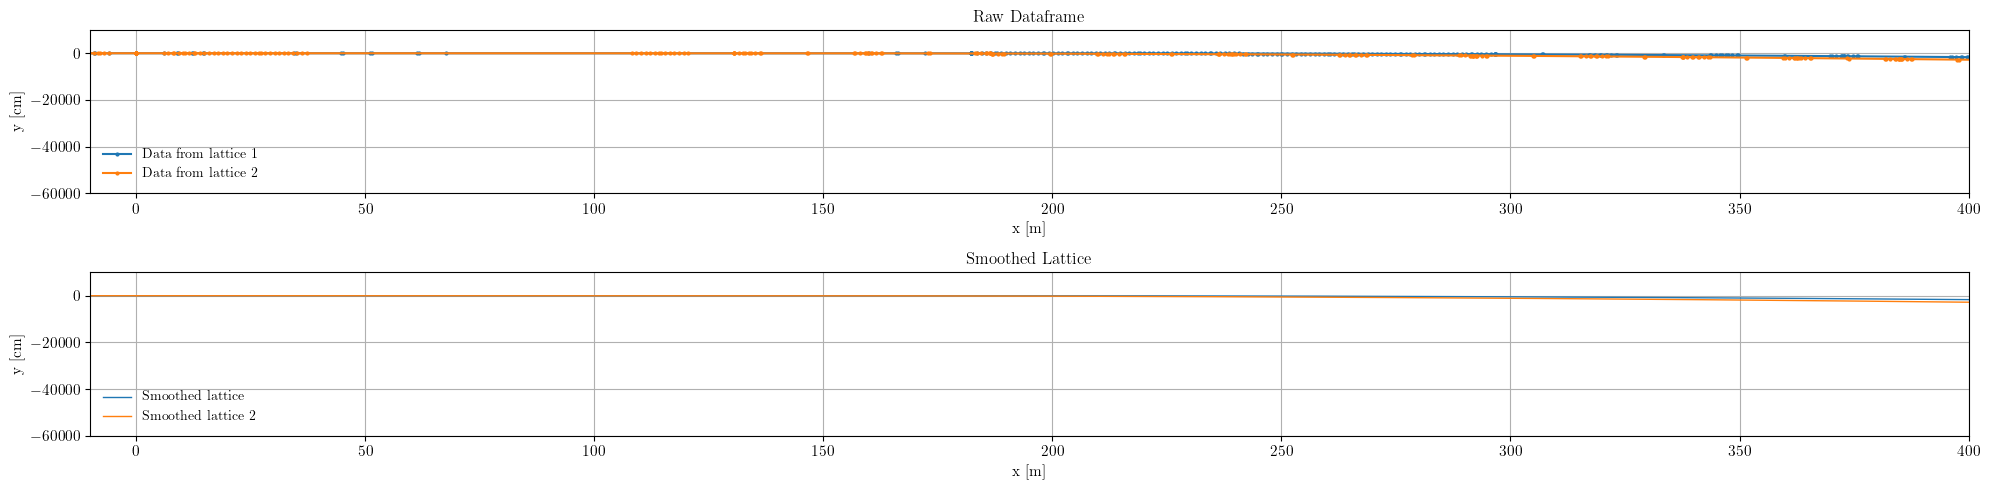

In [111]:
df, lattice_dict = df_IR_hybrid, lattice_dict_IR_hybrid
df_2, lattice_dict_2 = df_IR_v09_curves, lattice_dict_IR_v09_curves
df_2, lattice_dict_2 = df_10tev, lattice_dict_10tev
# Comparing lattices
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 5))

# Raw dataframe points
ax1.plot(df['x'], df['y']*100, 'o-', markersize=2, label='Data from lattice 1')
ax1.plot(df_2['x'], df_2['y']*100, 'o-', markersize=2, label='Data from lattice 2')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [cm]')
ax1.set_title('Raw Dataframe')
ax1.legend()

# Smoothed lattice
u_full = np.linspace(0, 1, 5000)
ax2.plot(lattice_dict['x'](u_full)*1e-2, lattice_dict['y'](u_full), '-', linewidth=1, label='Smoothed lattice')
ax2.plot(lattice_dict_2['x'](u_full)*1e-2, lattice_dict_2['y'](u_full), '-', linewidth=1, label='Smoothed lattice 2')
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [cm]')
ax2.set_title('Smoothed Lattice')
ax2.legend()

for ax in (ax1, ax2):
    ax.grid(True)
    ax.set_ylim(-60000, 10000)
    ax.set_xlim(-10, 400)

plt.tight_layout()

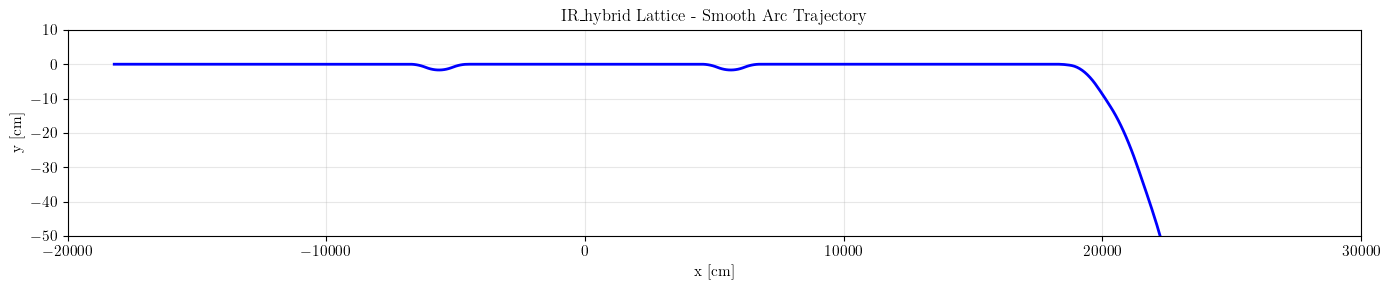

In [130]:
fig, ax = plt.subplots(1, 1, figsize=(14, 3))
u_full = np.linspace(0, 1, 2000)
ax.plot(lattice_dict_IR_hybrid['x'](u_full), lattice_dict_IR_hybrid['y'](u_full), 'b-', linewidth=2)
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_ylim(-0.5e2, 1e1)
ax.set_xlim(-2e4, 3e4)
ax.set_title('IR_hybrid Lattice - Smooth Arc Trajectory')
ax.grid(True, alpha=0.3)
plt.tight_layout()

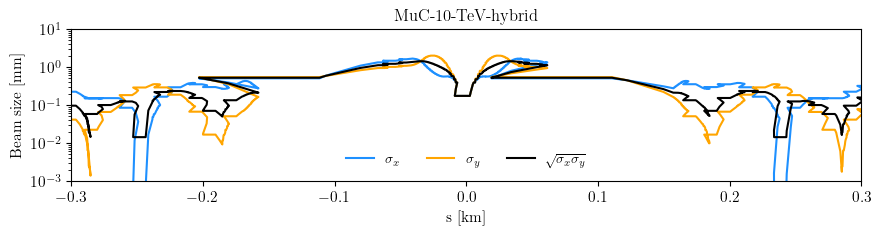

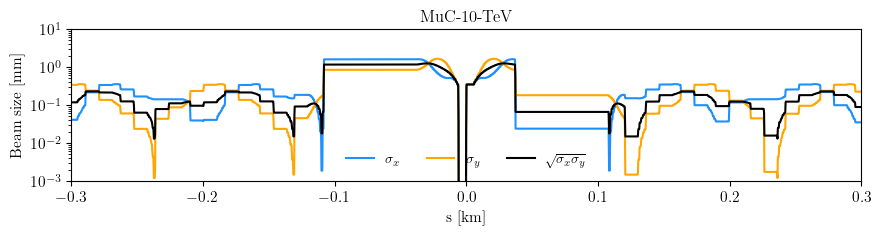

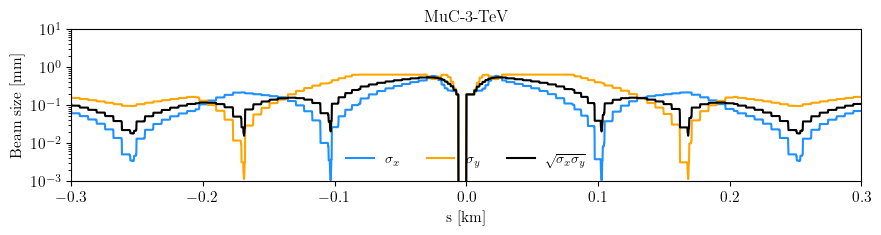

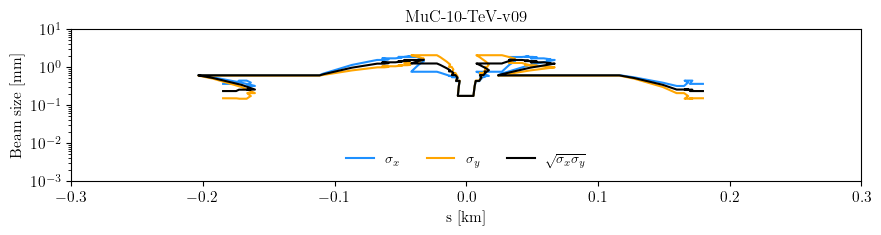

In [131]:
for name, lattice in zip(['MuC-10-TeV-hybrid', 'MuC-10-TeV', 'MuC-3-TeV', 'MuC-10-TeV-v09'], [lattice_dict_IR_hybrid, lattice_dict_10tev, lattice_dict_3tev, lattice_dict_IR_v09]):
    if name == 'MuC-10-TeV-v09' or name == 'MuC-10-TeV-hybrid':
        u = np.linspace(0, 1, 10_000, endpoint=True)
    else:
        u = np.linspace(0.4, 0.6, 10_000, endpoint=True)

    s_middle = const.cm_to_km * lattice['s'](1) / 2

    fig, ax = pt.std_fig(figsize=(10, 2))

    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, lattice['beamsize_x'](u), color='dodgerblue', label='$\sigma_x$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, lattice['beamsize_y'](u), color='orange', label='$\sigma_y$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, np.sqrt(lattice['beamsize_y'](u) * lattice['beamsize_x'](u)), color='black', label='$\sqrt{\sigma_x \sigma_y}$')

    ax.legend(loc='lower center', ncol=3)
    ax.set_yscale('log')
    ax.set_xlim(-0.3,0.3)
    ax.set_xlabel("s [km]")
    ax.set_ylabel("Beam size [mm]")
    ax.set_ylim(1e-3,10)
    ax.set_title(f"{name}")
    fig.savefig(f'plots/beam_optics/beam_size_{name}.pdf', bbox_inches='tight', dpi=300)

In [132]:
# Check how beta functions vary along the lattice
print("Beta function values for first 15 elements:")
print(df_IR_hybrid[['NAME', 'S', 'L', 'BETX', 'BETY']].head(15).to_string())

Beta function values for first 15 elements:
          NAME           S          L           BETX           BETY
0    IR1$START    0.000000   0.000000   17057.113609    5042.766858
1    START_IR1    0.000000   0.000000   17057.113609    5042.766858
2   START_IR1L    0.000000   0.000000   17057.113609    5042.766858
3         IDR3    5.000000  10.000000   25802.050613    4513.519897
4         IQF3   13.000000   6.000000   38331.670601    4257.372046
5           DR   16.150000   0.300000   30142.430074    5876.057280
6         IQD2   19.300000   6.000000   19992.651886    8410.120590
7         IDR2   68.426776  92.253552   74167.081716   70332.940438
8          IB2  117.553552   6.000000  468437.642446  191293.008728
9           DR  120.703552   0.300000  505301.835638  201071.419959
10         IB1  125.853552  10.000000  568572.604287  217583.333580
11          DR  131.003552   0.300000  635563.696718  234746.737492
12         IB3  134.153552   6.000000  678372.516692  245565.850578
13  

In [133]:
# Reload module and recreate lattices with the beam size interpolation fix
import importlib
importlib.reload(lt)

print("Recreating lattices with interpolated beta functions...")
lattice_dict_IR_hybrid = lt.create_smoothed_lattice(df_IR_hybrid, n_elements=5_000, emittance_RMS=emittance_RMS)
lattice_dict_3tev  = lt.create_smoothed_lattice(df_3tev, n_elements=50_000, emittance_RMS=emittance_RMS)
lattice_dict_10tev = lt.create_smoothed_lattice(df_10tev, n_elements=50_000, emittance_RMS=emittance_RMS)
lattice_dict_IR_v09_straight = lt.create_smoothed_lattice(df_IR_v09_straight, n_elements=5_000, emittance_RMS=emittance_RMS)
print("Done!")

Recreating lattices with interpolated beta functions...
Done!


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_57282/3479786409.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


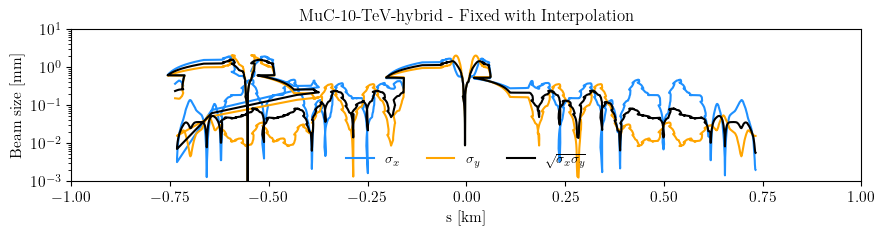

In [ ]:
# Test the fixed beam size for the hybrid lattice
name, lattice = 'MuC-10-TeV-hybrid', lattice_dict_IR_hybrid
u = np.linspace(0, 1, 10_000, endpoint=True)
s_middle = const.cm_to_km * lattice['s'](1) / 2

fig, ax = pt.std_fig(figsize=(10, 2))

ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, lattice['beamsize_x'](u), color='dodgerblue', label='$\sigma_x$')
ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, lattice['beamsize_y'](u), color='orange', label='$\sigma_y$')
ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, np.sqrt(lattice['beamsize_y'](u) * lattice['beamsize_x'](u)), color='black', label='$\sqrt{\sigma_x \sigma_y}$')

ax.legend(loc='lower center', ncol=3)
ax.set_yscale('log')
ax.set_xlim(-1, 1)
ax.set_xlabel("s [km]")
ax.set_ylabel("Beam size [mm]")
ax.set_ylim(1e-3,10)
ax.set_title(f"{name} - Fixed with Interpolation")
plt.tight_layout()

Number of points where s decreases: 332
First few decreasing points at indices: [ 90  91 123 124 681 682 739 740 774 775]
s values around first decrease:
  s[90] = 1567.5563
  s[91] = 1414.3624
  Decrease: -153.1938


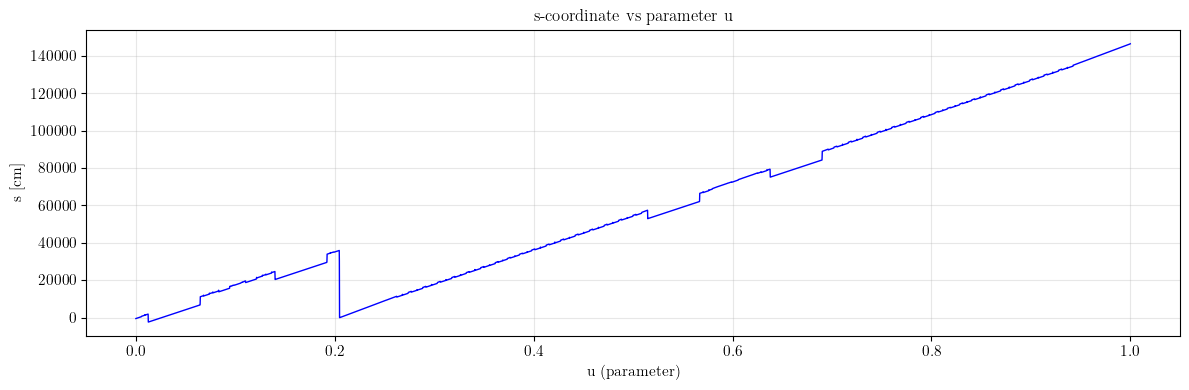

In [136]:
# Check if s is monotonically increasing
u = np.linspace(0, 1, 10_000)
s_values = lattice_dict_IR_hybrid['s'](u)

# Check for non-monotonic behavior
s_diff = np.diff(s_values)
decreasing_points = np.where(s_diff < 0)[0]

print(f"Number of points where s decreases: {len(decreasing_points)}")
if len(decreasing_points) > 0:
    print(f"First few decreasing points at indices: {decreasing_points[:10]}")
    print(f"s values around first decrease:")
    idx = decreasing_points[0]
    print(f"  s[{idx}] = {s_values[idx]:.4f}")
    print(f"  s[{idx+1}] = {s_values[idx+1]:.4f}")
    print(f"  Decrease: {s_diff[idx]:.4f}")

# Plot s vs u to visualize
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(u, s_values, 'b-', linewidth=1)
ax.set_xlabel('u (parameter)')
ax.set_ylabel('s [cm]')
ax.set_title('s-coordinate vs parameter u')
ax.grid(True, alpha=0.3)
plt.tight_layout()

Recreating lattices with corrected s-coordinate...
Done!

Number of points where s decreases: 316


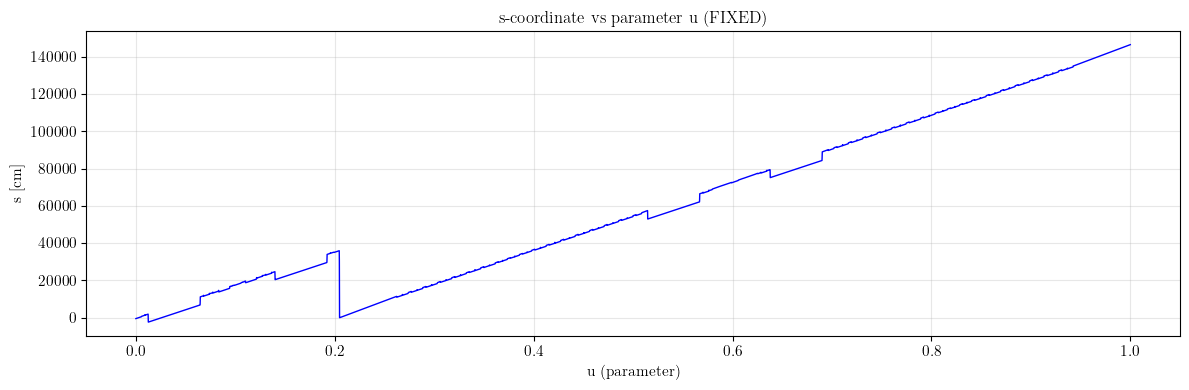

In [137]:
# Reload with the corrected s-coordinate fix
import importlib
importlib.reload(lt)

print("Recreating lattices with corrected s-coordinate...")
lattice_dict_IR_hybrid_fixed = lt.create_smoothed_lattice(df_IR_hybrid, n_elements=5_000, emittance_RMS=emittance_RMS)
print("Done!")

# Check if s is now monotonic
u = np.linspace(0, 1, 10_000)
s_values = lattice_dict_IR_hybrid_fixed['s'](u)
s_diff = np.diff(s_values)
decreasing_points = np.where(s_diff < 0)[0]

print(f"\nNumber of points where s decreases: {len(decreasing_points)}")

# Plot s vs u
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(u, s_values, 'b-', linewidth=1)
ax.set_xlabel('u (parameter)')
ax.set_ylabel('s [cm]')
ax.set_title('s-coordinate vs parameter u (FIXED)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
# Check the S coordinates in the hybrid dataframe
print("First lattice S range:")
print(f"  Min: {df_IR_v09_straight['S'].min():.2f} m")
print(f"  Max: {df_IR_v09_straight['S'].max():.2f} m")

print("\nSecond lattice S range:")
print(f"  Min: {df_IR_v09_curves['S'].min():.2f} m")
print(f"  Max: {df_IR_v09_curves['S'].max():.2f} m")

print("\nHybrid lattice S values:")
print(f"  Min: {df_IR_hybrid['S'].min():.2f} m")
print(f"  Max: {df_IR_hybrid['S'].max():.2f} m")
print(f"  First 5: {df_IR_hybrid['S'].head().values}")
print(f"  Around junction (rows 50-55): {df_IR_hybrid['S'].iloc[50:56].values}")
print(f"  Last 5: {df_IR_hybrid['S'].tail().values}")

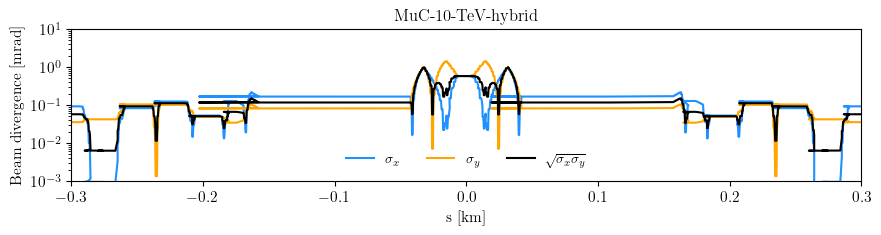

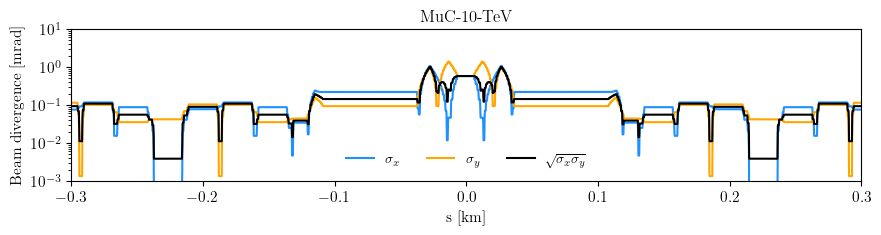

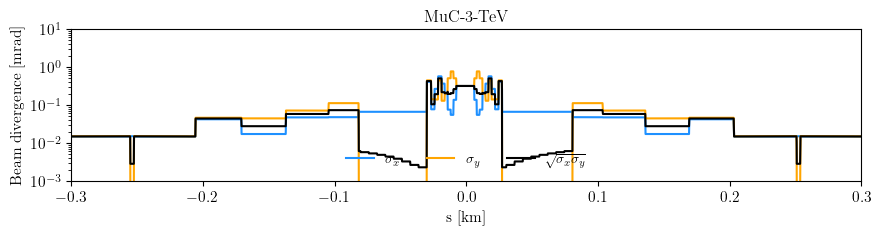

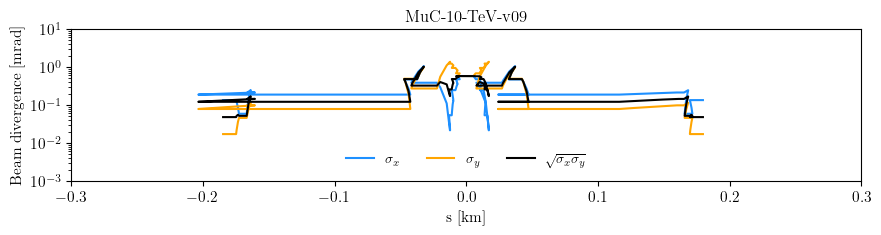

In [100]:
for name, lattice in zip(['MuC-10-TeV-hybrid', 'MuC-10-TeV', 'MuC-3-TeV', 'MuC-10-TeV-v09'], [lattice_dict_IR_hybrid, lattice_dict_10tev, lattice_dict_3tev, lattice_dict_IR_v09]):
    if name == 'MuC-10-TeV-v09' or name == 'MuC-10-TeV-hybrid':
        u = np.linspace(0, 1, 10_000, endpoint=True)
    else:
        u = np.linspace(0.4, 0.6, 10_000, endpoint=True)

    s_middle = const.cm_to_km * lattice['s'](1) / 2

    fig, ax = pt.std_fig(figsize=(10, 2))

    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, 1e3*lattice['beamdiv_x'](u), color='dodgerblue', label='$\sigma_x$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, 1e3*lattice['beamdiv_y'](u), color='orange', label='$\sigma_y$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, 1e3*np.sqrt(lattice['beamdiv_y'](u) * lattice['beamdiv_x'](u)), color='black', label='$\sqrt{\sigma_x \sigma_y}$')

    ax.legend(loc='lower center', ncol=3)
    ax.set_yscale('log')
    ax.set_xlim(-0.3,0.3)
    ax.set_xlabel("s [km]")
    ax.set_ylabel("Beam divergence [mrad]")
    ax.set_ylim(1e-3,10)
    ax.set_title(f"{name}")
    fig.savefig(f'plots/beam_optics/beam_divergence_{name}.pdf', bbox_inches='tight', dpi=300)

In [42]:
beta_star = 1.5e-3 # meters
gamma_factor = 5e3/const.m_mu
area = np.pi*beta_star * emittance_RMS * const.m_to_cm**2 # cm^2

Nmu = 1.8e12
f = const.c_LIGHT/8.6688e5
print(f"MuC Luminosity: {Nmu**2 * f / 4 / area:.2g} cm^-2 s^-1")


MuC Luminosity: 1.2e+36 cm^-2 s^-1


# RCS lattices

Loading up all RCS rings

In [43]:
twiss_file_path_RCS1_ext = "beam-optics/rcs1_ds_ext.tfs"
df_RCS1_ext = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS1_ext)
lattice_dict_RCS1_ext  = lt.create_smoothed_lattice(df_RCS1_ext, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_RCS2_ext = "beam-optics/rcs2_ds_ext.tfs"
df_RCS2_ext = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS2_ext)
lattice_dict_RCS2_ext  = lt.create_smoothed_lattice(df_RCS2_ext, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_RCS3_ext = "beam-optics/rcs3_ds_ext.tfs"
df_RCS3_ext = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS3_ext)
lattice_dict_RCS3_ext  = lt.create_smoothed_lattice(df_RCS3_ext, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_RCS4_ext = "beam-optics/rcs4_ds_ext.tfs"
df_RCS4_ext = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS4_ext)
lattice_dict_RCS4_ext  = lt.create_smoothed_lattice(df_RCS4_ext, n_elements=50_000, emittance_RMS=emittance_RMS)


twiss_file_path_RCS1_inj = "beam-optics/rcs1_ds_inj.tfs"
df_RCS1_inj = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS1_inj)
lattice_dict_RCS1_inj  = lt.create_smoothed_lattice(df_RCS1_inj, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_RCS2_inj = "beam-optics/rcs2_ds_inj.tfs"
df_RCS2_inj = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS2_inj)
lattice_dict_RCS2_inj  = lt.create_smoothed_lattice(df_RCS2_inj, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_RCS3_inj = "beam-optics/rcs3_ds_inj.tfs"
df_RCS3_inj = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS3_inj)
lattice_dict_RCS3_inj  = lt.create_smoothed_lattice(df_RCS3_inj, n_elements=50_000, emittance_RMS=emittance_RMS)

twiss_file_path_RCS4_inj = "beam-optics/rcs4_ds_inj.tfs"
df_RCS4_inj = lt.get_lattice_dataframe_from_tfs(twiss_file_path_RCS4_inj)
lattice_dict_RCS4_inj  = lt.create_smoothed_lattice(df_RCS4_inj, n_elements=50_000, emittance_RMS=emittance_RMS)


KeyboardInterrupt: 

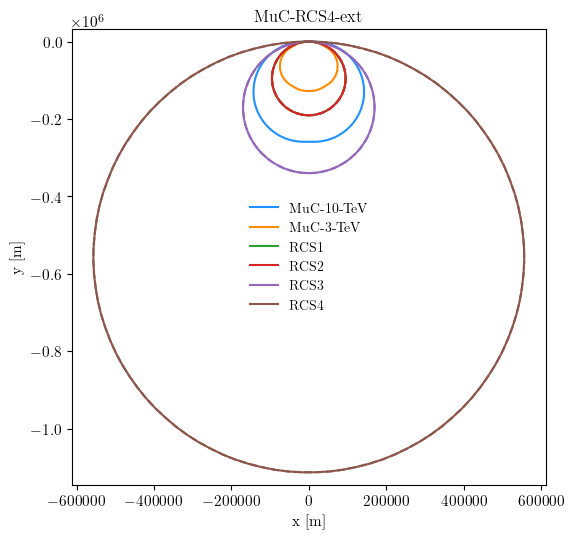

In [6]:
fig, ax = pt.std_fig(figsize=(6, 6))

u = np.linspace(0, 1, 100)

colors = {
    'MuC-10-TeV': 'dodgerblue',
    'MuC-3-TeV': 'darkorange',
    'RCS1-inj': 'tab:green',
    'RCS1-ext': 'tab:green',
    'RCS2-inj': 'tab:red',
    'RCS2-ext': 'tab:red',
    'RCS3-inj': 'tab:purple',
    'RCS3-ext': 'tab:purple',
    'RCS4-inj': 'tab:brown',
    'RCS4-ext': 'tab:brown'
}

for name, lattice in zip(
    ['MuC-10-TeV', 'MuC-3-TeV', 'RCS1-inj', 'RCS1-ext', 'RCS2-inj', 'RCS2-ext', 'RCS3-inj', 'RCS3-ext', 'RCS4-inj', 'RCS4-ext'],
    [lattice_dict_10tev, lattice_dict_3tev, lattice_dict_RCS1_inj, lattice_dict_RCS1_ext, lattice_dict_RCS2_inj, lattice_dict_RCS2_ext, lattice_dict_RCS3_inj, lattice_dict_RCS3_ext, lattice_dict_RCS4_inj, lattice_dict_RCS4_ext]
):
    if '-ext' in name:
        ax.plot(lattice['x'](u), lattice['y'](u), color=colors[name], linestyle='--',zorder=2)
    else:    
        ax.plot(lattice['x'](u), lattice['y'](u), color=colors[name], label=name.replace('-inj', ''), zorder=2)
ax.legend()
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"MuC-{name}")
ax.axis('equal')
fig.savefig(f'beam-optics/ring_{name}.pdf', bbox_inches='tight', dpi=300)


In [101]:
for name, lattice in zip(['MuC-10-TeV', 'MuC-3-TeV', 'RCS1-inj', 'RCS1-ext', 'RCS2-inj', 'RCS2-ext', 'RCS3-inj', 'RCS3-ext', 'RCS4-inj', 'RCS4-ext'], [lattice_dict_10tev, lattice_dict_3tev, lattice_dict_RCS1_inj, lattice_dict_RCS1_ext, lattice_dict_RCS2_inj, lattice_dict_RCS2_ext, lattice_dict_RCS3_inj, lattice_dict_RCS3_ext, lattice_dict_RCS4_inj, lattice_dict_RCS4_ext]):
    u = np.linspace(1, 0, 1_000, endpoint=True)
    s_middle = const.cm_to_km * lattice['s'](1) / 2

    fig, ax = pt.std_fig(figsize=(10, 2))

    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, lattice['beamsize_x'](u), color='dodgerblue', label='$\sigma_x$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, lattice['beamsize_y'](u), color='orange', label='$\sigma_y$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, np.sqrt(lattice['beamsize_y'](u) * lattice['beamsize_x'](u)), color='black', label='$\sqrt{\sigma_x \sigma_y}$')

    ax.legend(loc='lower center', ncol=3)
    ax.set_yscale('log')
    ax.set_xlim(-s_middle, s_middle)
    ax.set_xlabel("s [km]")
    ax.set_ylabel("Beam envelope size [cm]")
    ax.set_ylim(1e-3,2)
    ax.set_title(f"{name}")
    fig.savefig(f'plots/beam_optics/beam_envelope_{name}.pdf', bbox_inches='tight', dpi=300)

NameError: name 'lattice_dict_RCS1_inj' is not defined

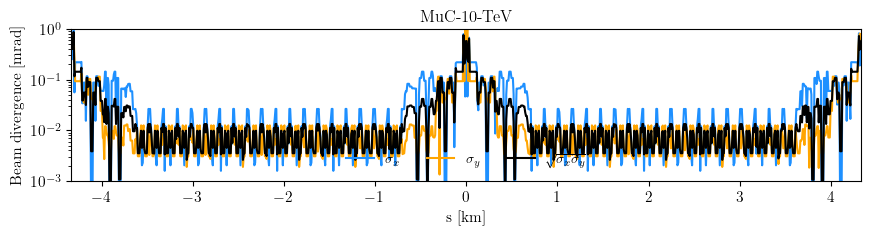

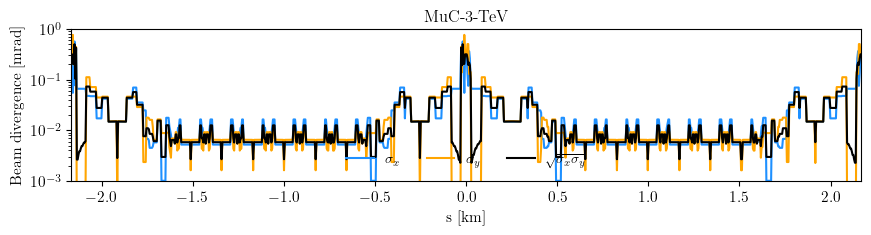

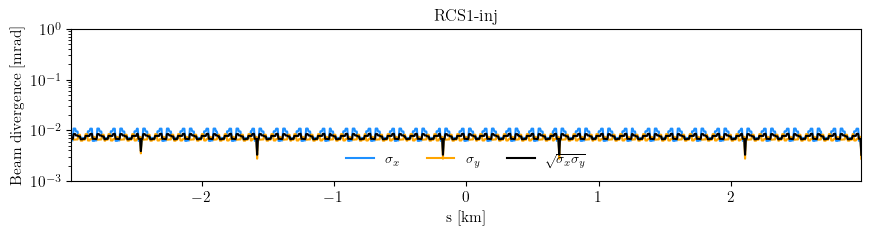

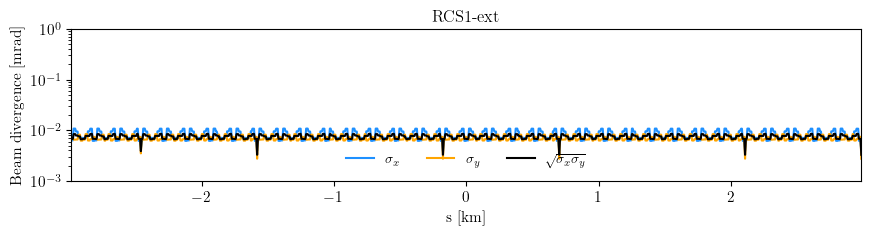

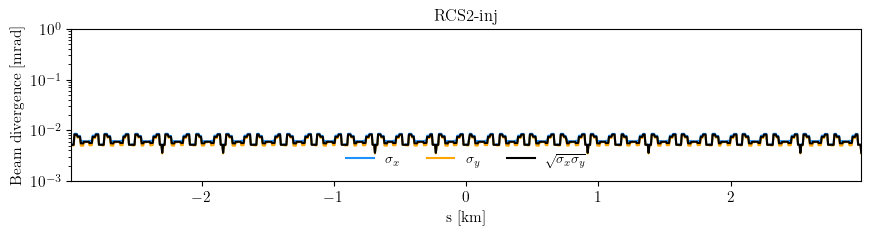

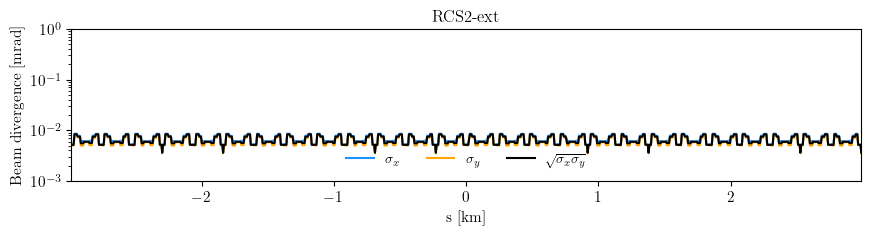

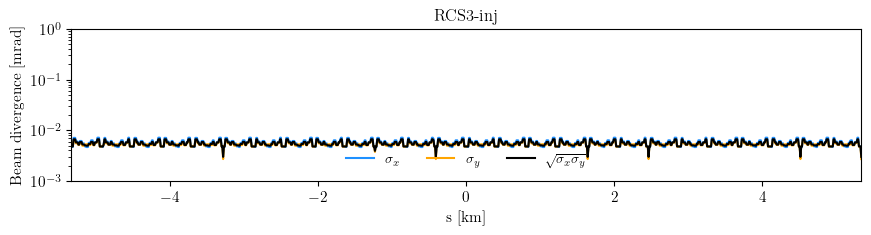

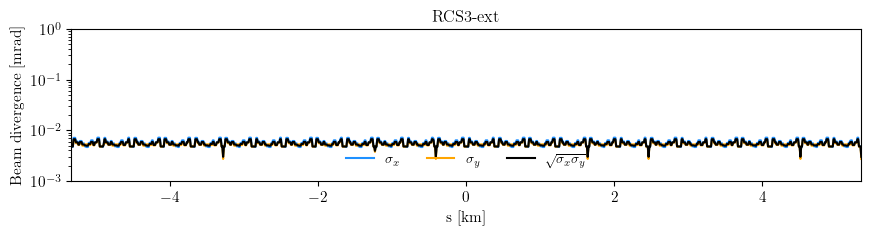

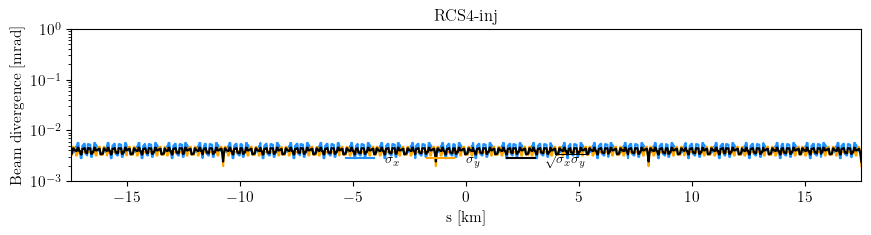

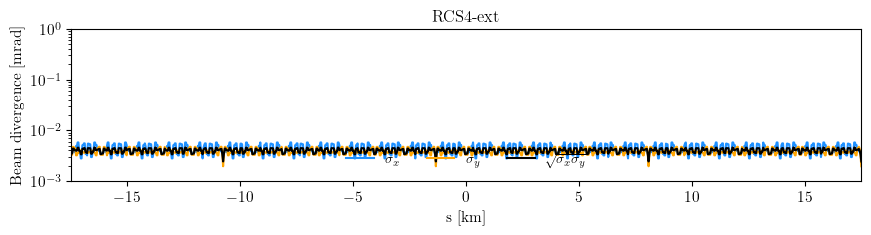

In [15]:
for name, lattice in zip(['MuC-10-TeV', 'MuC-3-TeV', 'RCS1-inj', 'RCS1-ext', 'RCS2-inj', 'RCS2-ext', 'RCS3-inj', 'RCS3-ext', 'RCS4-inj', 'RCS4-ext'], [lattice_dict_10tev, lattice_dict_3tev, lattice_dict_RCS1_inj, lattice_dict_RCS1_ext, lattice_dict_RCS2_inj, lattice_dict_RCS2_ext, lattice_dict_RCS3_inj, lattice_dict_RCS3_ext, lattice_dict_RCS4_inj, lattice_dict_RCS4_ext]):
    u = np.linspace(1, 0, 1_000, endpoint=True)
    s_middle = const.cm_to_km * lattice['s'](1) / 2

    fig, ax = pt.std_fig(figsize=(10, 2))

    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, 1e3*lattice['beamdiv_x'](u), color='dodgerblue', label='$\sigma_x$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, 1e3*lattice['beamdiv_y'](u), color='orange', label='$\sigma_y$')
    ax.plot(const.cm_to_km*lattice['s'](u)-s_middle, 1e3*np.sqrt(lattice['beamdiv_y'](u) * lattice['beamdiv_x'](u)), color='black', label='$\sqrt{\sigma_x \sigma_y}$')

    ax.legend(loc='lower center', ncol=3)
    ax.set_yscale('log')
    ax.set_xlim(-s_middle, s_middle)
    ax.set_xlabel("s [km]")
    ax.set_ylabel("Beam divergence [mrad]")
    ax.set_ylim(1e-3,1)
    ax.set_title(f"{name}")
    fig.savefig(f'plots/beam_optics/beam_divergence_{name}.pdf', bbox_inches='tight', dpi=300)

In [51]:
with open('beam-optics/ring_v06_df.pkl', 'wb') as f:
    pickle.dump(df_10tev, f)

with open('beam-optics/ring_3tev_v1.2_df.pkl', 'wb') as f:
    pickle.dump(df_3tev, f)

with open('beam-optics/ring_IR_v09.pkl', 'wb') as f:
    pickle.dump(df_IR_v09, f)

In [57]:
df_10tev.to_pickle('beam-optics/ring_v06_df.pkl')
df_3tev.to_pickle('beam-optics/ring_3tev_v1.2_df.pkl')
df_IR_v09.to_pickle('beam-optics/ring_IR_v09.pkl')

In [58]:
with open('beam-optics/ring_v06_smoothed.pkl', 'wb') as f:
    pickle.dump(lattice_dict_10tev, f)

with open('beam-optics/ring_3tev_v1.2_smoothed.pkl', 'wb') as f:
    pickle.dump(lattice_dict_3tev, f)

with open('beam-optics/ring_IR_v09_smoothed.pkl', 'wb') as f:
    pickle.dump(lattice_dict_IR_v09, f)

In [59]:
with open('beam-optics/ring_v06_smoothed.pkl', 'rb') as f:
    lattice_10TeV = pickle.load(f)
with open('beam-optics/ring_3tev_v1.2_smoothed.pkl', 'rb') as f:
    lattice_3TeV = pickle.load(f)
with open('beam-optics/ring_IR_v09_smoothed.pkl', 'rb') as f:
    lattice_10TeV_v09 = pickle.load(f)

# Plotting only the colliders

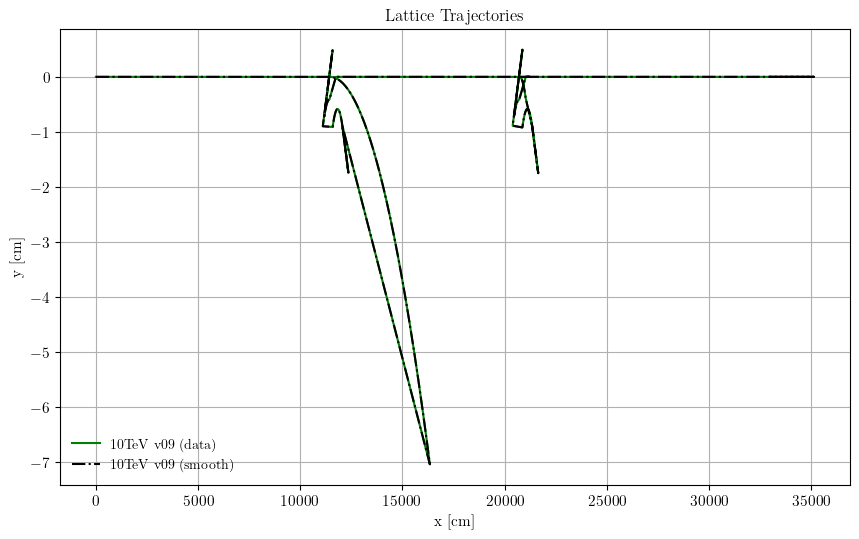

In [60]:
u = np.linspace(0, 1, 1000)

fig, ax = pt.std_fig(figsize=(10, 6))

# ax.plot(lattice_3TeV['x'](u), lattice_3TeV['y'](u), label='3TeV (data)', color='dodgerblue')
# ax.plot(lattice_10TeV['x'](u), lattice_10TeV['y'](u), label='10TeV (data)', color='darkorange')
ax.plot(lattice_10TeV_v09['x'](u), lattice_10TeV_v09['y'](u), label='10TeV v09 (data)', color='green')
# ax.plot(lattice_dict_3tev['x'](u), lattice_dict_3tev['y'](u), ls='--', c='black', label='3TeV (smooth)')
# ax.plot(lattice_dict_10tev['x'](u), lattice_dict_10tev['y'](u), ls=':', c='black', label='10TeV (smooth)')
ax.plot(lattice_dict_IR_v09['x'](u), lattice_dict_IR_v09['y'](u), ls='-.', c='black', label='10TeV v09 (smooth)')


ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_title('Lattice Trajectories')
ax.legend()
ax.grid(True)
# ax.axis('equal')
# ax.set_xlim(-1e4, 1e4)
# ax.set_ylim(-1e3, 1e3)
# fig.savefig('plots/beam_optics/lattice_trajectories.pdf', bbox_inches='tight', dpi=300)

## Plotting cells

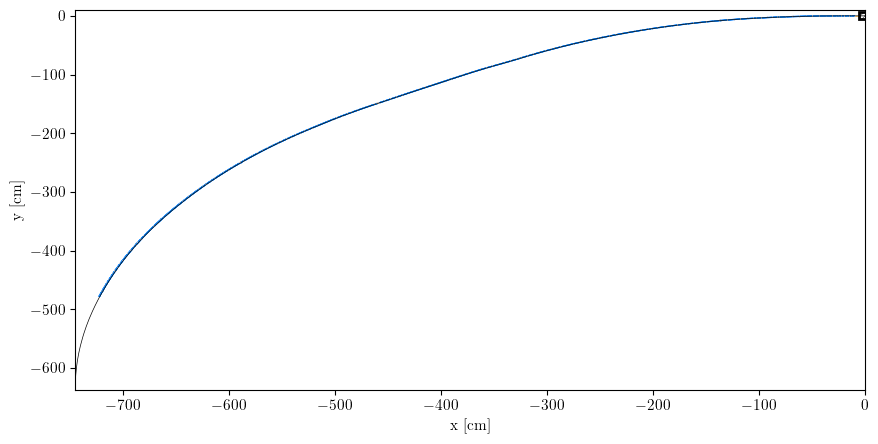

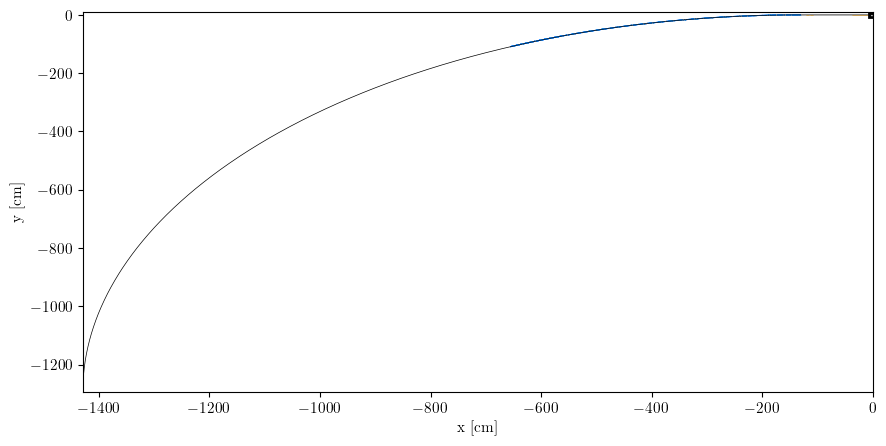

In [434]:
lt.plot_lattice(df_3tev)
lt.plot_lattice(df_10tev)

## Some old experiments with smooth geometrical shapes

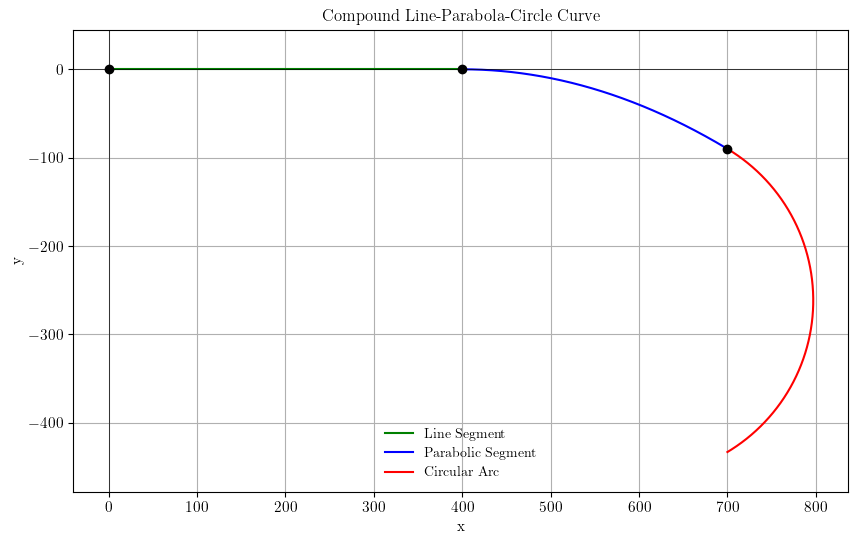

In [472]:
import numpy as np
import matplotlib.pyplot as plt

def plot_compound_curve(P0, L, Lq, radius, num_points=1000, n_degree=2, coeff=1):
    # Straight Line Calculation
    direction = np.array([1, 0])  # Starting with a horizontal direction
    P1 = P0 + direction * L

    vertex = P1
    parabola_x = np.linspace(0, Lq, num_points)
    parabola_y = -coeff * parabola_x**n_degree
    parabolic_points = np.column_stack((P1[0] + parabola_x, P1[1] + parabola_y))

    # Transition point coordinates (end of parabola, start of circle)
    P2 = parabolic_points[-1]

    # Circle center should be such that the tangent at P2 matches parabola's tangent
    tangent_slope = -(n_degree) * coeff * parabola_x[-1]**(n_degree-1)
    tangent_angle = np.arctan(tangent_slope)

    # Assume P2 is on the circle and we know its slope
    theta_start = tangent_angle+np.pi/2  # Start from this
    center = P2 - radius * np.array([np.cos(theta_start), np.sin(theta_start)])

    # Define the arc itself
    theta_end = -theta_start
    theta_arc = np.linspace(theta_start, theta_end, num_points)
    arc_points = np.zeros((num_points, 2))
    arc_points[:, 0] = center[0] + radius * np.cos(theta_arc)
    arc_points[:, 1] = center[1] + radius * np.sin(theta_arc)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot([P0[0], P1[0]], [P0[1], P1[1]], 'g-', label='Line Segment')
    plt.plot(parabolic_points[:, 0], parabolic_points[:, 1], 'b-', label='Parabolic Segment')
    plt.plot(arc_points[:, 0], arc_points[:, 1], 'r-', label='Circular Arc')

    plt.scatter(*zip(P0, P1, P2), color='black', zorder=5)
    plt.title('Compound Line-Parabola-Circle Curve')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Example usage
start_point = np.array([0, 0])
line_length = 400
parabolic_length = 300
circle_radius = 200

plot_compound_curve(start_point, line_length, parabolic_length, circle_radius, n_degree=2, coeff=0.001)